In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import neurokit2 as nk
from pathlib import Path

In [23]:
# Set plot style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
BASE_PATH = Path(r"E:\Graduation Project\maestro\CASE_full\CASE_full\data\interpolated")
ANNOTATIONS_DIR = BASE_PATH / "annotations"
PHYSIO_DIR = BASE_PATH / "physiological" # Assuming this is the name of the physio folder

def load_subject_data(subject_id, original_hz=1000, target_hz=20):
    """
    Loads and merges the physiological and annotation data for a single subject.
    """
    # Construct file paths
    annot_file = ANNOTATIONS_DIR / f"sub_{subject_id}.csv"
    physio_file = PHYSIO_DIR / f"sub_{subject_id}.csv"
    
    # Check if files exist before trying to load
    if not annot_file.exists() or not physio_file.exists():
        raise FileNotFoundError(f"Could not find data for Subject {subject_id}. Check your folder names.")
        
    # Load the CSVs
    print(f"Loading Subject {subject_id}...")
    annot_df = pd.read_csv(annot_file)
    signal_df = pd.read_csv(physio_file)
    
    # Check the columns in the CASE dataset (they might be capitalized or named slightly differently)
    # Usually they are 'daqtime', 'ecg', 'bvp', 'eda', 'resp', 'skt' (skin temp)
    # We will map them to our expected lowercase names for the pipeline
    col_mapping = {'bvp': 'bvp', 'eda': 'eda', 'skt': 'st'} 
    
    # Downsample the physiological signals
    downsample_factor = original_hz // target_hz
    resampled_signals = {}
    
    for raw_col, new_col in col_mapping.items():
        if raw_col in signal_df.columns:
            resampled_signals[new_col] = signal.resample_poly(signal_df[raw_col], up=1, down=downsample_factor)
        else:
            print(f"Warning: Column {raw_col} not found in physio data.")
            
    resampled_df = pd.DataFrame(resampled_signals)
    
    # Downsample the annotations to match (if they aren't already at 20Hz)
    # If the interpolated annotations are at 1000Hz, we downsample them too. 
    # If they are already at 20Hz, we can just slice them.
    # We'll use slicing for annotations assuming they match the downsampled length.
    
    min_len = min(len(resampled_df), len(annot_df))
    final_df = resampled_df.iloc[:min_len].copy()
    
    # Assuming the annotation columns are named 'valence' and 'arousal'
    final_df['valence'] = annot_df['valence'].iloc[:min_len].values
    final_df['arousal'] = annot_df['arousal'].iloc[:min_len].values
    
    return final_df

# --- Test loading Subject 1 ---
try:
    df_sub1 = load_subject_data(subject_id=1)
    print("Successfully loaded Subject 1!")
    print(df_sub1.head())
except Exception as e:
    print(e)

Loading Subject 1...
Successfully loaded Subject 1!
         bvp         st  valence  arousal
0  19.448207  15.039623      5.0      5.0
1  41.536095  32.068083      5.0      5.0
2  36.336693  28.187681      5.0      5.0
3  38.680387  30.279145      5.0      5.0
4  36.647078  28.979046      5.0      5.0


In [25]:
# Just reads the header of the CSV without loading the whole file
sample_physio = pd.read_csv(PHYSIO_DIR / "sub_1.csv", nrows=0)
print(sample_physio.columns.tolist())

['daqtime', 'ecg', 'bvp', 'gsr', 'rsp', 'skt', 'emg_zygo', 'emg_coru', 'emg_trap', 'video']


In [26]:
# Set your base path
BASE_PATH = Path(r"E:\Graduation Project\maestro\CASE_full\CASE_full\data\interpolated")
ANNOTATIONS_DIR = BASE_PATH / "annotations"
PHYSIO_DIR = BASE_PATH / "physiological" 

def load_subject_data(subject_id, original_hz=1000, target_hz=20):
    """
    Loads and merges the physiological and annotation data for a single subject.
    """
    annot_file = ANNOTATIONS_DIR / f"sub_{subject_id}.csv"
    physio_file = PHYSIO_DIR / f"sub_{subject_id}.csv"
    
    if not annot_file.exists() or not physio_file.exists():
        raise FileNotFoundError(f"Could not find data for Subject {subject_id}.")
        
    print(f"Loading Subject {subject_id}...")
    annot_df = pd.read_csv(annot_file)
    signal_df = pd.read_csv(physio_file)
    
    # Updated Mapping: 'gsr' maps to 'eda', 'skt' maps to 'st'
    col_mapping = {'bvp': 'bvp', 'gsr': 'eda', 'skt': 'st'} 
    
    downsample_factor = original_hz // target_hz
    resampled_signals = {}
    
    for raw_col, new_col in col_mapping.items():
        if raw_col in signal_df.columns:
            resampled_signals[new_col] = signal.resample_poly(signal_df[raw_col], up=1, down=downsample_factor)
        else:
            print(f"Warning: Column {raw_col} not found in physio data.")
            
    resampled_df = pd.DataFrame(resampled_signals)
    
    min_len = min(len(resampled_df), len(annot_df))
    final_df = resampled_df.iloc[:min_len].copy()
    
    final_df['valence'] = annot_df['valence'].iloc[:min_len].values
    final_df['arousal'] = annot_df['arousal'].iloc[:min_len].values
    
    return final_df

# --- Test loading Subject 1 ---
df_sub1 = load_subject_data(subject_id=1)
print("Successfully loaded Subject 1! Warning should be gone.")
print(df_sub1.head())

Loading Subject 1...
Successfully loaded Subject 1! Warning should be gone.
         bvp        eda         st  valence  arousal
0  19.448207   5.986243  15.039623      5.0      5.0
1  41.536095  12.756175  32.068083      5.0      5.0
2  36.336693  11.204792  28.187681      5.0      5.0
3  38.680387  12.032621  30.279145      5.0      5.0
4  36.647078  11.512105  28.979046      5.0      5.0


In [27]:
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

class CASEEmotionDataset(Dataset):
    def __init__(self, X, y_valence, y_arousal):
        """
        X: numpy array of shape (num_samples, sequence_length, num_features)
        y_valence: numpy array of shape (num_samples,)
        y_arousal: numpy array of shape (num_samples,)
        """
        # Convert numpy arrays to PyTorch float tensors
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_valence = torch.tensor(y_valence, dtype=torch.float32)
        self.y_arousal = torch.tensor(y_arousal, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_valence[idx], self.y_arousal[idx]

In [28]:
def create_sliding_windows(df, window_sec=5, step_sec=1, hz=20):
    window_len = window_sec * hz
    step_len = step_sec * hz
    
    X, y_v, y_a = [], [], []
    features = ['eda_tonic_norm', 'eda_phasic_norm', 'heart_rate_norm', 'st_clean_norm']
    
    # Slide over the dataframe
    for i in range(0, len(df) - window_len, step_len):
        # Extract the 5-second feature window
        X.append(df[features].iloc[i : i + window_len].values)
        
        # Extract the target emotion at the *end* of the window
        # (index i + window_len - 1 is the last timestep of the current window)
        y_v.append(df['valence'].iloc[i + window_len - 1])
        y_a.append(df['arousal'].iloc[i + window_len - 1])
        
    return np.array(X), np.array(y_v), np.array(y_a)

In [29]:
# Initialize empty lists to hold the windows for all subjects
all_X = []
all_y_valence = []
all_y_arousal = []

# Loop through all 30 subjects (1 to 30 inclusive)
print("Starting batch processing for all 30 subjects...")
for subject_id in tqdm(range(1, 31), desc="Processing Subjects"):
    try:
        # 1. Load and Resample (Using the function we built earlier)
        df_sub = load_subject_data(subject_id)
        
        # 2. Process EDA
        eda_signals, _ = nk.eda_process(df_sub['eda'], sampling_rate=20)
        df_sub['eda_tonic'] = eda_signals['EDA_Tonic']
        df_sub['eda_phasic'] = eda_signals['EDA_Phasic']
        
        # 3. Process BVP to HR
        bvp_cleaned = nk.ppg_clean(df_sub['bvp'], sampling_rate=20)
        info = nk.ppg_findpeaks(bvp_cleaned, sampling_rate=20)
        df_sub['heart_rate'] = nk.signal_rate(info["PPG_Peaks"], sampling_rate=20, desired_length=len(df_sub))
        
        # 4. Process Skin Temp
        b, a = signal.butter(2, 0.5, btype='low', fs=20)
        df_sub['st_clean'] = signal.filtfilt(b, a, df_sub['st'])
        
        # 5. Subject-Level Z-Score Normalization
        for col in ['eda_tonic', 'eda_phasic', 'heart_rate', 'st_clean']:
            mean_val = df_sub[col].mean()
            std_val = df_sub[col].std()
            df_sub[f'{col}_norm'] = (df_sub[col] - mean_val) / (std_val + 1e-8)
            
        # 6. Create Sliding Windows
        X_sub, y_v_sub, y_a_sub = create_sliding_windows(df_sub, window_sec=5, step_sec=1, hz=20)
        
        # 7. Append to master lists
        all_X.append(X_sub)
        all_y_valence.append(y_v_sub)
        all_y_arousal.append(y_a_sub)
        
    except FileNotFoundError:
        # Some datasets skip numbers (e.g., if a subject's data was corrupted)
        print(f"\nSkipping Subject {subject_id} - File not found.")
    except Exception as e:
        print(f"\nError processing Subject {subject_id}: {e}")

# Vertically stack all the subject arrays into massive global arrays
final_X = np.vstack(all_X)
final_y_valence = np.concatenate(all_y_valence)
final_y_arousal = np.concatenate(all_y_arousal)

print("\n--- Processing Complete! ---")
print(f"Total Dataset Shape: {final_X.shape}") # Expected: (Total_Windows, 100, 4)

Starting batch processing for all 30 subjects...


Processing Subjects:   0%|          | 0/30 [00:00<?, ?it/s]

Loading Subject 1...


Processing Subjects:   3%|▎         | 1/30 [00:02<01:17,  2.67s/it]

Loading Subject 2...


...

Loading Subject 29...


Processing Subjects:  97%|█████████▋| 29/30 [01:16<00:02,  2.62s/it]

Loading Subject 30...


Processing Subjects: 100%|██████████| 30/30 [01:19<00:00,  2.64s/it]


--- Processing Complete! ---
Total Dataset Shape: (73410, 100, 4)


In [30]:
# Create the Dataset
full_dataset = CASEEmotionDataset(final_X, final_y_valence, final_y_arousal)

# Create the DataLoader (Batch size of 64 or 128 is usually good for LSTMs)
train_loader = DataLoader(full_dataset, batch_size=64, shuffle=True, drop_last=True)

# Quick test to grab one batch
batch_X, batch_y_v, batch_y_a = next(iter(train_loader))
print(f"Batch X shape: {batch_X.shape}") 
print(f"Batch Valence shape: {batch_y_v.shape}")
print(f"Batch Arousal shape: {batch_y_a.shape}")

Batch X shape: torch.Size([64, 100, 4])
Batch Valence shape: torch.Size([64])
Batch Arousal shape: torch.Size([64])


In [31]:
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader
# from sklearn.model_selection import train_test_split
# import matplotlib.pyplot as plt

# # --- 1. Train/Validation Split ---
# print("Splitting data into 80% Training and 20% Validation...")
# X_train, X_val, y_v_train, y_v_val, y_a_train, y_a_val = train_test_split(
#     final_X, final_y_valence, final_y_arousal, test_size=0.2, random_state=42
# )

# # Create the DataLoaders
# train_dataset = CASEEmotionDataset(X_train, y_v_train, y_a_train)
# val_dataset = CASEEmotionDataset(X_val, y_v_val, y_a_val)

# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
# val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, drop_last=True)

# print(f"Training batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

# # --- 2. Bring in the Model and Loss ---
# # (Pasting the classes here so the cell runs cleanly)
# class DualLSTMEmotionRegressor(nn.Module):
#     def __init__(self, input_features, hidden_size, num_layers, dropout_rate=0.2):
#         super(DualLSTMEmotionRegressor, self).__init__()
#         self.input_projection = nn.Linear(input_features, hidden_size)
#         self.relu = nn.ReLU()
        
#         # Valence Branch
#         self.lstm_valence = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
#         self.fc_valence = nn.Sequential(
#             nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
#         )
        
#         # Arousal Branch
#         self.lstm_arousal = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
#         self.fc_arousal = nn.Sequential(
#             nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
#         )

#     def forward(self, x):
#         x_proj = self.relu(self.input_projection(x))
#         v_out, _ = self.lstm_valence(x_proj)
#         a_out, _ = self.lstm_arousal(x_proj)
#         return self.fc_valence(v_out[:, -1, :]), self.fc_arousal(a_out[:, -1, :])

# class DualEmotionLoss(nn.Module):
#     def __init__(self, alpha=0.5):
#         super(DualEmotionLoss, self).__init__()
#         self.mse = nn.MSELoss()
#         self.alpha = alpha
        
#     def forward(self, pred_v, target_v, pred_a, target_a):
#         return (self.alpha * self.mse(pred_v.squeeze(), target_v)) + ((1 - self.alpha) * self.mse(pred_a.squeeze(), target_a))

# # --- 3. Initialization ---
# # Setup device (Use GPU if available for massive speedup)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Training on device: {device}")

# # We have 4 features: eda_tonic, eda_phasic, heart_rate, st_clean
# model = DualLSTMEmotionRegressor(input_features=4, hidden_size=64, num_layers=2).to(device)
# criterion = DualEmotionLoss(alpha=0.5) # Equal weight to Valence and Arousal
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# # --- 4. The Training Loop ---
# epochs = 15
# train_losses, val_losses = [], []

# for epoch in range(epochs):
#     # Training Phase
#     model.train()
#     running_train_loss = 0.0
    
#     for batch_X, batch_y_v, batch_y_a in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
#         batch_X, batch_y_v, batch_y_a = batch_X.to(device), batch_y_v.to(device), batch_y_a.to(device)
        
#         optimizer.zero_grad()
#         pred_v, pred_a = model(batch_X)
#         loss = criterion(pred_v, batch_y_v, pred_a, batch_y_a)
        
#         loss.backward()
#         optimizer.step()
#         running_train_loss += loss.item()
        
#     avg_train_loss = running_train_loss / len(train_loader)
#     train_losses.append(avg_train_loss)
    
#     # Validation Phase
#     model.eval()
#     running_val_loss = 0.0
    
#     with torch.no_grad():
#         for batch_X, batch_y_v, batch_y_a in val_loader:
#             batch_X, batch_y_v, batch_y_a = batch_X.to(device), batch_y_v.to(device), batch_y_a.to(device)
#             pred_v, pred_a = model(batch_X)
#             loss = criterion(pred_v, batch_y_v, pred_a, batch_y_a)
#             running_val_loss += loss.item()
            
#     avg_val_loss = running_val_loss / len(val_loader)
#     val_losses.append(avg_val_loss)
    
#     print(f"Epoch {epoch+1} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# # --- 5. Plotting the Learning Curve ---

# plt.figure(figsize=(10, 5))
# plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
# plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Combined MSE Loss')
# plt.title('Dual-LSTM Learning Curve')
# plt.legend()
# plt.show()

# # Save the trained weights!
# torch.save(model.state_dict(), "maestro_affect_model.pth")
# print("Model saved successfully!")

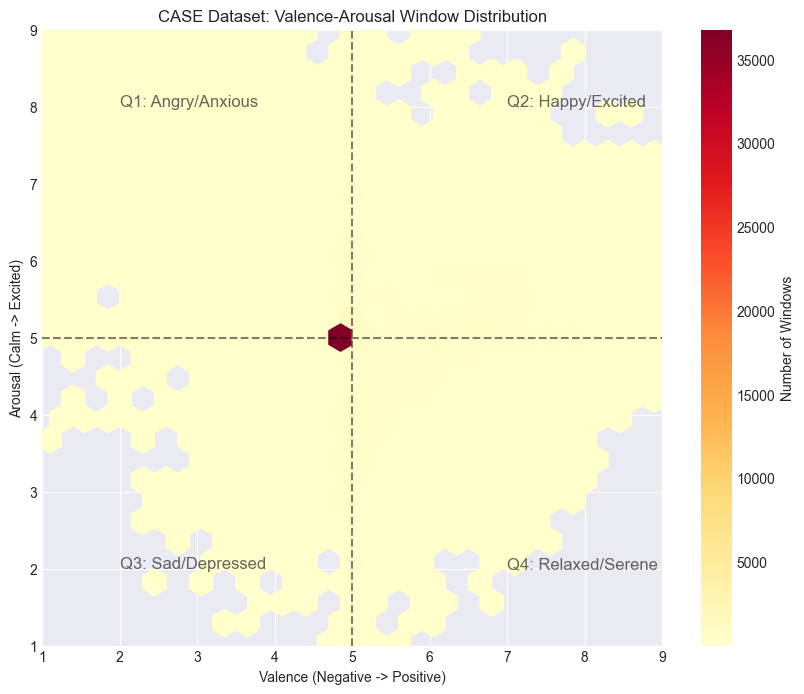

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of the entire dataset's targets
plt.figure(figsize=(10, 8))
plt.hexbin(final_y_valence, final_y_arousal, gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Number of Windows')

# Add quadrant lines (assuming a 1 to 9 scale, 5 is neutral)
plt.axvline(x=5, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=5, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Valence (Negative -> Positive)')
plt.ylabel('Arousal (Calm -> Excited)')
plt.title('CASE Dataset: Valence-Arousal Window Distribution')
plt.xlim(1, 9)
plt.ylim(1, 9)

# Annotate Quadrants
plt.text(2, 8, 'Q1: Angry/Anxious', fontsize=12, alpha=0.7)
plt.text(7, 8, 'Q2: Happy/Excited', fontsize=12, alpha=0.7)
plt.text(2, 2, 'Q3: Sad/Depressed', fontsize=12, alpha=0.7)
plt.text(7, 2, 'Q4: Relaxed/Serene', fontsize=12, alpha=0.7)

plt.show()

In [33]:
import numpy as np

def augment_minority_classes(X_train, y_v_train, y_a_train, target_val=5, target_aro=5):
    """
    Finds windows in the minority quadrants and creates synthetic copies
    using Jittering and Scaling.
    """
    print(f"Original Training Set Size: {len(X_train)}")
    
    # 1. Identify the minority quadrant (e.g., Low Valence, Low Arousal)
    # Adjust these conditions based on what your hexbin plot shows!
    minority_indices = np.where((y_v_train < target_val) & (y_a_train < target_aro))[0]
    print(f"Found {len(minority_indices)} minority windows. Augmenting...")
    
    X_minority = X_train[minority_indices]
    y_v_minority = y_v_train[minority_indices]
    y_a_minority = y_a_train[minority_indices]
    
    # Technique 1: Jittering (Adding Gaussian Noise)
    noise = np.random.normal(loc=0.0, scale=0.05, size=X_minority.shape)
    X_jittered = X_minority + noise
    
    # Technique 2: Scaling (Multiplying by a random scalar between 0.95 and 1.05)
    scalars = np.random.uniform(low=0.95, high=1.05, size=(X_minority.shape[0], 1, 1))
    X_scaled = X_minority * scalars
    
    # Stack everything together
    X_train_balanced = np.vstack((X_train, X_jittered, X_scaled))
    
    # The targets remain the same for the augmented physiological data
    y_v_train_balanced = np.concatenate((y_v_train, y_v_minority, y_v_minority))
    y_a_train_balanced = np.concatenate((y_a_train, y_a_minority, y_a_minority))
    
    print(f"New Balanced Training Set Size: {len(X_train_balanced)}")
    return X_train_balanced, y_v_train_balanced, y_a_train_balanced

# Apply this strictly to the training split you made earlier
# X_train_bal, y_v_train_bal, y_a_train_bal = augment_minority_classes(X_train, y_v_train, y_a_train)

In [34]:
import numpy as np

# --- 1. Subject-Wise Split ---
print("Executing Subject-Wise Split...")
num_subjects = len(all_X)
split_idx = int(num_subjects * 0.8) # 80% Train (e.g., first 24 subjects), 20% Val (last 6 subjects)

# Stack the lists into our separated arrays
X_train_sub = np.vstack(all_X[:split_idx])
y_v_train = np.concatenate(all_y_valence[:split_idx])
y_a_train = np.concatenate(all_y_arousal[:split_idx])

X_val_final = np.vstack(all_X[split_idx:])
y_v_val_final = np.concatenate(all_y_valence[split_idx:])
y_a_val_final = np.concatenate(all_y_arousal[split_idx:])

print(f"Initial Training Windows: {len(X_train_sub)} | Validation Windows: {len(X_val_final)}")

# --- 2. Downsampling the "Neutral" Majority ---
# Find all windows that are exactly or very close to (5.0, 5.0)
neutral_indices = np.where((np.abs(y_v_train - 5.0) < 0.5) & (np.abs(y_a_train - 5.0) < 0.5))[0]
non_neutral_indices = np.setdiff1d(np.arange(len(y_v_train)), neutral_indices)

print(f"Found {len(neutral_indices)} neutral windows. Dropping 75% of them...")

# Randomly select only 25% of the neutral indices to keep
np.random.seed(42)
keep_neutral = np.random.choice(neutral_indices, size=int(len(neutral_indices) * 0.25), replace=False)

# Combine the kept neutrals with all the non-neutrals
balanced_indices = np.concatenate((non_neutral_indices, keep_neutral))
np.random.shuffle(balanced_indices) # Shuffle them up

X_train_downsampled = X_train_sub[balanced_indices]
y_v_train_down = y_v_train[balanced_indices]
y_a_train_down = y_a_train[balanced_indices]

# --- 3. Augmenting the Extremes (Jittering & Scaling) ---
# Let's find the "extreme" emotions (e.g., Valence < 3.5 or > 6.5, Arousal < 3.5 or > 6.5)
extreme_indices = np.where(
    (y_v_train_down < 3.5) | (y_v_train_down > 6.5) | 
    (y_a_train_down < 3.5) | (y_a_train_down > 6.5)
)[0]

print(f"Found {len(extreme_indices)} extreme emotion windows. Generating synthetic biological data...")

X_extremes = X_train_downsampled[extreme_indices]
y_v_extremes = y_v_train_down[extreme_indices]
y_a_extremes = y_a_train_down[extreme_indices]

# Augmentation 1: Jittering (Adding tiny Gaussian noise)
noise = np.random.normal(loc=0.0, scale=0.03, size=X_extremes.shape)
X_jittered = X_extremes + noise

# Augmentation 2: Scaling (Multiplying by a random scalar between 0.95 and 1.05)
scalars = np.random.uniform(low=0.95, high=1.05, size=(X_extremes.shape[0], 1, 1))
X_scaled = X_extremes * scalars

# --- 4. Finalizing the Training Set ---
X_train_final = np.vstack((X_train_downsampled, X_jittered, X_scaled))
y_v_train_final = np.concatenate((y_v_train_down, y_v_extremes, y_v_extremes))
y_a_train_final = np.concatenate((y_a_train_down, y_a_extremes, y_a_extremes))

print(f"\nFinal Balanced Training Windows: {len(X_train_final)}")

Executing Subject-Wise Split...
Initial Training Windows: 58728 | Validation Windows: 14682
Found 32205 neutral windows. Dropping 75% of them...
Found 16517 extreme emotion windows. Generating synthetic biological data...

Final Balanced Training Windows: 67608


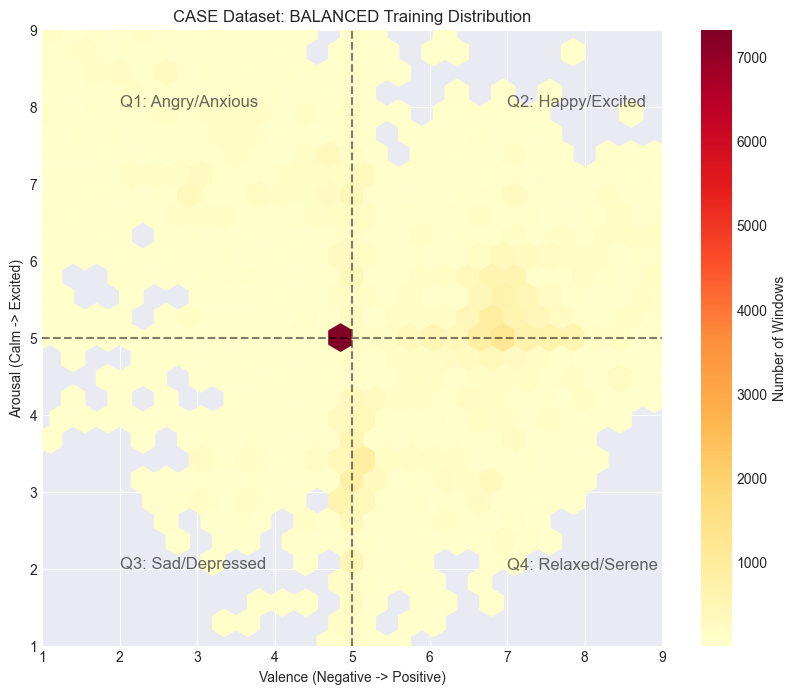

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# Using the NEW balanced training targets
plt.hexbin(y_v_train_final, y_a_train_final, gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Number of Windows')

plt.axvline(x=5, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=5, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Valence (Negative -> Positive)')
plt.ylabel('Arousal (Calm -> Excited)')
plt.title('CASE Dataset: BALANCED Training Distribution')
plt.xlim(1, 9)
plt.ylim(1, 9)

plt.text(2, 8, 'Q1: Angry/Anxious', fontsize=12, alpha=0.7)
plt.text(7, 8, 'Q2: Happy/Excited', fontsize=12, alpha=0.7)
plt.text(2, 2, 'Q3: Sad/Depressed', fontsize=12, alpha=0.7)
plt.text(7, 2, 'Q4: Relaxed/Serene', fontsize=12, alpha=0.7)

plt.show()

In [36]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# --- Advanced Time-Series Augmentation Functions ---

def generate_random_curve(x, sigma=0.2, knot=4):
    """Generates a smooth random curve using Cubic Splines for Magnitude Warping."""
    # Create random anchor points (knots)
    x_knots = np.arange(0, x.shape[1], x.shape[1] // knot)
    # The knots around 1.0 (mean) with variance sigma
    y_knots = np.random.normal(loc=1.0, scale=sigma, size=(x.shape[0], len(x_knots), x.shape[2]))
    
    # Interpolate a smooth curve through the knots for all windows and features
    x_range = np.arange(x.shape[1])
    warped_curves = np.zeros_like(x)
    
    for i in range(x.shape[0]):
        for f in range(x.shape[2]):
            cs = CubicSpline(x_knots, y_knots[i, :, f])
            warped_curves[i, :, f] = cs(x_range)
            
    return warped_curves

def in_class_mixup(X_minority, y_v_minority, y_a_minority, alpha=0.5):
    """Blends two random samples from the same minority class."""
    n_samples = X_minority.shape[0]
    
    # Shuffle the indices to pair up different samples
    indices = np.random.permutation(n_samples)
    X_shuffled = X_minority[indices]
    y_v_shuffled = y_v_minority[indices]
    y_a_shuffled = y_a_minority[indices]
    
    # Blend the signals
    X_mixed = (alpha * X_minority) + ((1 - alpha) * X_shuffled)
    
    # The new target is the average of the two blended targets
    y_v_mixed = (alpha * y_v_minority) + ((1 - alpha) * y_v_shuffled)
    y_a_mixed = (alpha * y_a_minority) + ((1 - alpha) * y_a_shuffled)
    
    return X_mixed, y_v_mixed, y_a_mixed

# --- Integrating into the Pipeline ---

print(f"Found {len(extreme_indices)} extreme emotion windows. Applying Advanced Augmentations...")

# Isolate the minority data
X_extremes = X_train_downsampled[extreme_indices]
y_v_extremes = y_v_train_down[extreme_indices]
y_a_extremes = y_a_train_down[extreme_indices]

# Technique 1: Magnitude Warping
smooth_curves = generate_random_curve(X_extremes, sigma=0.15, knot=5)
X_warped = X_extremes * smooth_curves

# Technique 2: In-Class Mixup
# We will generate two batches of mixed data using different blending ratios
X_mixed_1, y_v_mixed_1, y_a_mixed_1 = in_class_mixup(X_extremes, y_v_extremes, y_a_extremes, alpha=0.6)
X_mixed_2, y_v_mixed_2, y_a_mixed_2 = in_class_mixup(X_extremes, y_v_extremes, y_a_extremes, alpha=0.4)

# --- Finalizing the Advanced Training Set ---
X_train_final = np.vstack((
    X_train_downsampled, 
    X_warped, 
    X_mixed_1, 
    X_mixed_2
))

y_v_train_final = np.concatenate((
    y_v_train_down, 
    y_v_extremes,    # Target for warped is same as original
    y_v_mixed_1, 
    y_v_mixed_2
))

y_a_train_final = np.concatenate((
    y_a_train_down, 
    y_a_extremes,    # Target for warped is same as original
    y_a_mixed_1, 
    y_a_mixed_2
))

print(f"Final Advanced Balanced Training Windows: {len(X_train_final)}")

Found 16517 extreme emotion windows. Applying Advanced Augmentations...
Final Advanced Balanced Training Windows: 84125


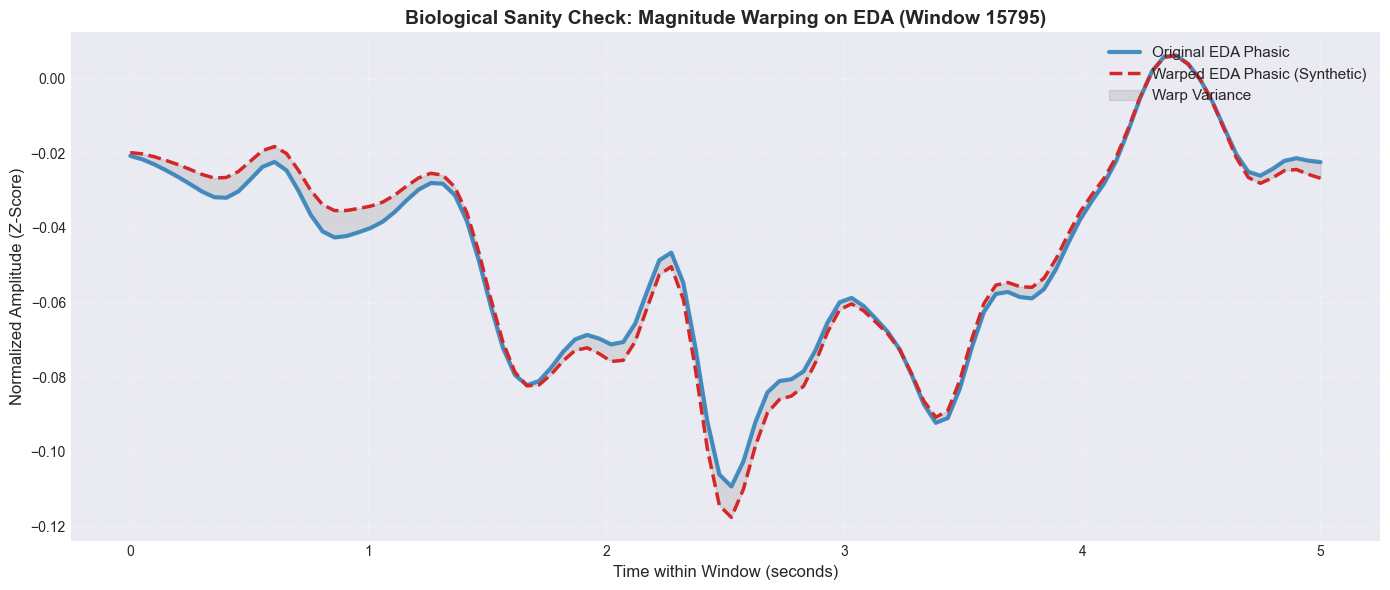

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a random index from our extreme windows to inspect
# You can change this number or leave it random to check different samples
np.random.seed(42) # Set seed for reproducible visualization
sample_idx = np.random.randint(0, len(X_extremes))

# The features array is: [eda_tonic, eda_phasic, heart_rate, st_clean]
# Index 1 is eda_phasic_norm (the sudden spikes that correlate with Arousal)
original_eda_phasic = X_extremes[sample_idx, :, 1] 
warped_eda_phasic = X_warped[sample_idx, :, 1]

# Time axis (5 seconds at 20Hz = 100 timesteps)
time_axis = np.linspace(0, 5, 100)

# Create the plot
plt.figure(figsize=(14, 6))

# Plotting them overlapping is the best way to see the distortion
plt.plot(time_axis, original_eda_phasic, label='Original EDA Phasic', color='#1f77b4', linewidth=3, alpha=0.8)
plt.plot(time_axis, warped_eda_phasic, label='Warped EDA Phasic (Synthetic)', color='#d62728', linestyle='--', linewidth=2.5)

# Adding some visual flair and labels
plt.title(f'Biological Sanity Check: Magnitude Warping on EDA (Window {sample_idx})', fontsize=14, fontweight='bold')
plt.xlabel('Time within Window (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude (Z-Score)', fontsize=12)

# Highlight the area between the curves to show the applied variance
plt.fill_between(time_axis, original_eda_phasic, warped_eda_phasic, color='gray', alpha=0.2, label='Warp Variance')

plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

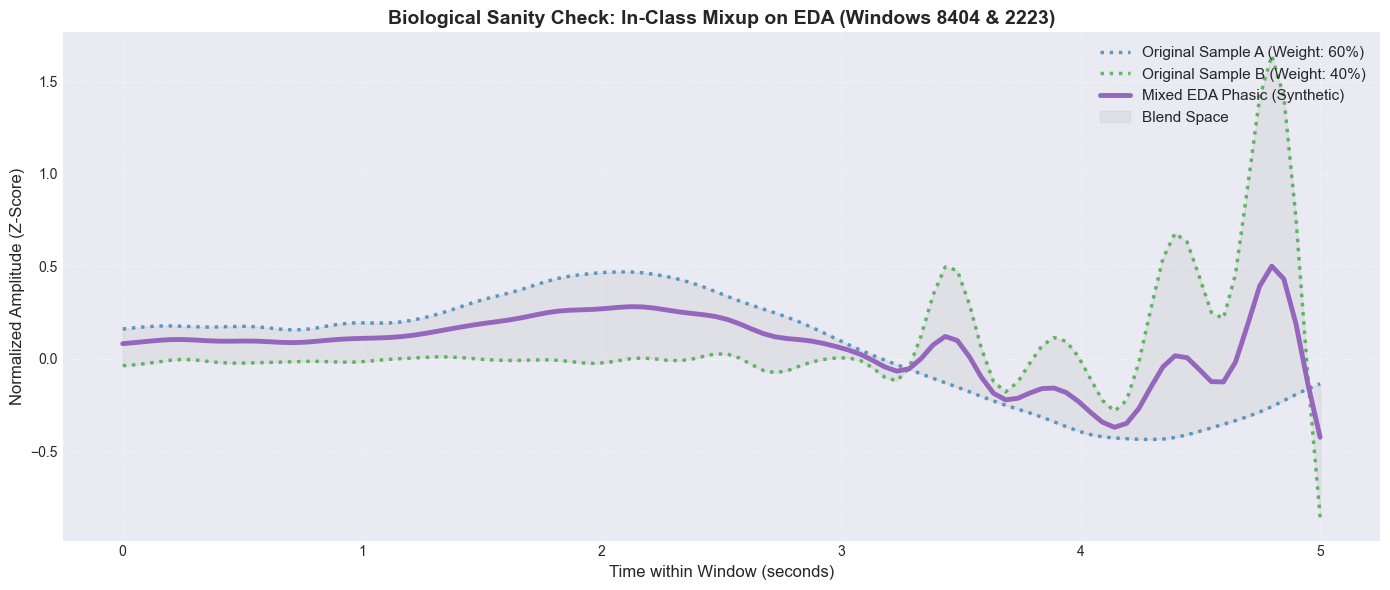

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Pick two random indices from our extreme windows
np.random.seed(101) # Different seed for variety
idx_A, idx_B = np.random.choice(len(X_extremes), 2, replace=False)

alpha = 0.6 # The blending ratio we used in the previous step

# Extract the Phasic EDA for both samples (Feature index 1)
eda_A = X_extremes[idx_A, :, 1]
eda_B = X_extremes[idx_B, :, 1]

# Manually apply the mixup formula for visualization
eda_mixed = (alpha * eda_A) + ((1 - alpha) * eda_B)

# Time axis (5 seconds at 20Hz = 100 timesteps)
time_axis = np.linspace(0, 5, 100)

# Create the plot
plt.figure(figsize=(14, 6))

# Plot the originals as dotted lines
plt.plot(time_axis, eda_A, label=f'Original Sample A (Weight: {alpha*100:.0f}%)', color='#1f77b4', linestyle=':', linewidth=2.5, alpha=0.7)
plt.plot(time_axis, eda_B, label=f'Original Sample B (Weight: {(1-alpha)*100:.0f}%)', color='#2ca02c', linestyle=':', linewidth=2.5, alpha=0.7)

# Plot the synthetic mixup as a solid, bold line
plt.plot(time_axis, eda_mixed, label='Mixed EDA Phasic (Synthetic)', color='#9467bd', linewidth=3.5)

# Visual flair
plt.title(f'Biological Sanity Check: In-Class Mixup on EDA (Windows {idx_A} & {idx_B})', fontsize=14, fontweight='bold')
plt.xlabel('Time within Window (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude (Z-Score)', fontsize=12)

# Highlight the blending space
plt.fill_between(time_axis, eda_A, eda_B, color='gray', alpha=0.1, label='Blend Space')

plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Initializing DataLoaders with the final augmented Subject-Wise splits...
Training on device: cuda


Epoch 1/20 [Train]: 100%|██████████| 1314/1314 [00:11<00:00, 117.08it/s]


Epoch 1 -> Train Loss: 4.2801 | Val Loss: 1.9541


Epoch 2/20 [Train]: 100%|██████████| 1314/1314 [00:09<00:00, 133.59it/s]


Epoch 2 -> Train Loss: 3.2780 | Val Loss: 1.8635


...

Epoch 18 -> Train Loss: 2.2561 | Val Loss: 2.3775


Epoch 19/20 [Train]: 100%|██████████| 1314/1314 [00:09<00:00, 135.94it/s]


Epoch 19 -> Train Loss: 2.2358 | Val Loss: 2.2935


Epoch 20/20 [Train]: 100%|██████████| 1314/1314 [00:09<00:00, 133.22it/s]


Epoch 20 -> Train Loss: 2.2153 | Val Loss: 2.3296


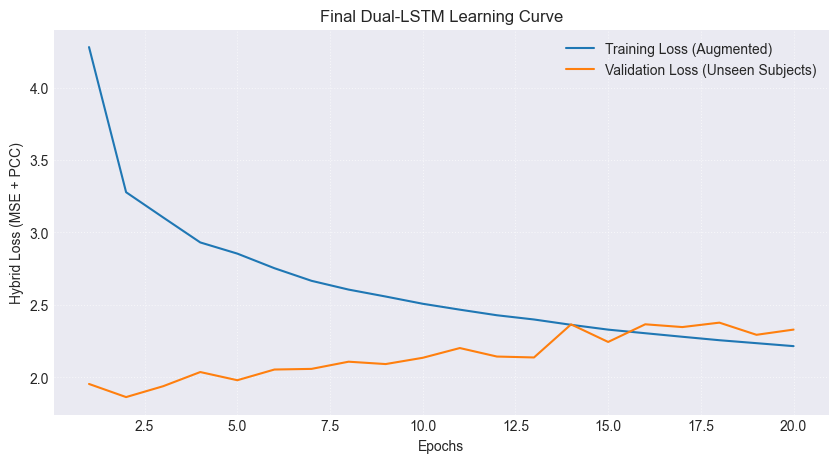


Success! Model saved as maestro_affect_model_advanced.pth


In [41]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. Load the Advanced Balanced Data ---
print("Initializing DataLoaders with the final augmented Subject-Wise splits...")
train_dataset = CASEEmotionDataset(X_train_final, y_v_train_final, y_a_train_final)
val_dataset = CASEEmotionDataset(X_val_final, y_v_val_final, y_a_val_final) # Untouched validation data!

# Batch size of 64 provides a good balance of speed and gradient stability
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, drop_last=True)

# --- 2. Initialize Model and Hybrid Loss ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Fresh initialization of the model to clear any old weights
model = DualLSTMEmotionRegressor(input_features=4, hidden_size=64, num_layers=2).to(device)

# Define the PCCHybridLoss class
class PCCHybridLoss(nn.Module):
    def __init__(self, alpha=0.5):
        """
        Combines Mean Squared Error (MSE) and Pearson Correlation Coefficient (PCC) as a hybrid loss.
        alpha: Weight for MSE loss. (1 - alpha) is the weight for PCC loss.
        """
        super(PCCHybridLoss, self).__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()

    def forward(self, pred_v, target_v, pred_a, target_a):
        # Compute MSE loss for valence and arousal
        mse_loss = self.mse(pred_v.squeeze(), target_v) + self.mse(pred_a.squeeze(), target_a)

        # Compute PCC loss for valence
        pred_v_centered = pred_v - pred_v.mean()
        target_v_centered = target_v - target_v.mean()
        pcc_v = torch.sum(pred_v_centered * target_v_centered) / (
            torch.sqrt(torch.sum(pred_v_centered**2)) * torch.sqrt(torch.sum(target_v_centered**2)) + 1e-8
        )

        # Compute PCC loss for arousal
        pred_a_centered = pred_a - pred_a.mean()
        target_a_centered = target_a - target_a.mean()
        pcc_a = torch.sum(pred_a_centered * target_a_centered) / (
            torch.sqrt(torch.sum(pred_a_centered**2)) * torch.sqrt(torch.sum(target_a_centered**2)) + 1e-8
        )

        # Combine MSE and PCC losses
        pcc_loss = 1 - (pcc_v + pcc_a) / 2  # PCC loss is 1 - PCC
        return self.alpha * mse_loss + (1 - self.alpha) * pcc_loss

# Using alpha=0.5: Model cares 50% about absolute error (MSE) and 50% about wave shape (PCC)
criterion = PCCHybridLoss(alpha=0.5) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) 

# --- 3. Training Loop ---
epochs = 20
train_losses, val_losses = [], []

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y_v, batch_y_a in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        batch_X = batch_X.to(device)
        batch_y_v = batch_y_v.to(device)
        batch_y_a = batch_y_a.to(device)
        
        optimizer.zero_grad()
        pred_v, pred_a = model(batch_X)
        loss = criterion(pred_v, batch_y_v, pred_a, batch_y_a)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients in LSTMs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y_v, batch_y_a in val_loader:
            batch_X = batch_X.to(device)
            batch_y_v = batch_y_v.to(device)
            batch_y_a = batch_y_a.to(device)
            
            pred_v, pred_a = model(batch_X)
            loss = criterion(pred_v, batch_y_v, pred_a, batch_y_a)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# --- 4. Plot Final Learning Curve ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss (Augmented)')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss (Unseen Subjects)')
plt.xlabel('Epochs')
plt.ylabel('Hybrid Loss (MSE + PCC)')
plt.title('Final Dual-LSTM Learning Curve')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- 5. Save the Weights ---
torch.save(model.state_dict(), "maestro_affect_model_advanced.pth")
print("\nSuccess! Model saved as maestro_affect_model_advanced.pth")

In [42]:
import torch
import torch.nn as nn

class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        # Learns to assign a score to each timestep
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # lstm_out shape: (batch_size, seq_len, hidden_size)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1) # Shape: (batch, seq_len, 1)
        
        # Multiply weights by lstm_out and sum across the sequence length to get the context
        context = torch.sum(attn_weights * lstm_out, dim=1) # Shape: (batch, hidden_size)
        return context

class DualLSTMAttentionRegressor(nn.Module):
    def __init__(self, input_features, hidden_size, num_layers, dropout_rate=0.4):
        super(DualLSTMAttentionRegressor, self).__init__()
        
        self.input_projection = nn.Linear(input_features, hidden_size)
        self.relu = nn.ReLU()
        
        # --- Valence Branch ---
        self.lstm_valence = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_valence = TemporalAttention(hidden_size)
        self.fc_valence = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )
        
        # --- Arousal Branch ---
        self.lstm_arousal = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_arousal = TemporalAttention(hidden_size)
        self.fc_arousal = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        x_proj = self.relu(self.input_projection(x))
        
        v_out, _ = self.lstm_valence(x_proj)
        # Instead of just taking the last timestep v_out[:, -1, :], we use Attention!
        v_context = self.attn_valence(v_out) 
        
        a_out, _ = self.lstm_arousal(x_proj)
        a_context = self.attn_arousal(a_out)
        
        return self.fc_valence(v_context), self.fc_arousal(a_context)

In [43]:
# Initialize Model with Attention and Higher Dropout
model = DualLSTMAttentionRegressor(input_features=4, hidden_size=64, num_layers=2).to(device)

criterion = PCCHybridLoss(alpha=0.5) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # Increased weight decay

# This will cut the learning rate in half if the validation loss stops improving for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [44]:
import torch
import torch.nn as nn

class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # Calculate attention scores for every millisecond in the window
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1) 
        # Create a weighted average of the window's features
        context = torch.sum(attn_weights * lstm_out, dim=1) 
        return context

class DualLSTMAttentionRegressor(nn.Module):
    def __init__(self, input_features, hidden_size, num_layers, dropout_rate=0.4):
        super(DualLSTMAttentionRegressor, self).__init__()
        self.input_projection = nn.Linear(input_features, hidden_size)
        self.relu = nn.ReLU()
        
        # Valence Branch [cite: 22, 146]
        self.lstm_valence = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_valence = TemporalAttention(hidden_size)
        self.fc_valence = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )
        
        # Arousal Branch [cite: 22, 146]
        self.lstm_arousal = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_arousal = TemporalAttention(hidden_size)
        self.fc_arousal = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        x_proj = self.relu(self.input_projection(x))
        v_out, _ = self.lstm_valence(x_proj)
        v_context = self.attn_valence(v_out) 
        a_out, _ = self.lstm_arousal(x_proj)
        a_context = self.attn_arousal(a_out)
        return self.fc_valence(v_context), self.fc_arousal(a_context)

In [45]:
# Initialize Model with Attention
model = DualLSTMAttentionRegressor(input_features=4, hidden_size=64, num_layers=2).to(device)

# Hybrid Loss (MSE + PCC) [cite: 90, 107, 108]
criterion = PCCHybridLoss(alpha=0.5) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Dynamic Learning Rate Adjustment
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ... inside your training loop ...
# avg_val_loss = running_val_loss / len(val_loader)
scheduler.step(avg_val_loss) # Tells the scheduler to check progress

In [46]:
# Initialize Model with Attention
model = DualLSTMAttentionRegressor(input_features=4, hidden_size=64, num_layers=2).to(device)

# Hybrid Loss (MSE + PCC) [cite: 90, 107, 108]
criterion = PCCHybridLoss(alpha=0.5) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Dynamic Learning Rate Adjustment
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ... inside your training loop ...
# avg_val_loss = running_val_loss / len(val_loader)
scheduler.step(avg_val_loss) # Tells the scheduler to check progress

Epoch 1/25: 100%|██████████| 1314/1314 [00:11<00:00, 114.18it/s]


Loss: 1.8689 | LR: 0.001


Epoch 2/25: 100%|██████████| 1314/1314 [00:10<00:00, 119.64it/s]


Loss: 1.8233 | LR: 0.001


Epoch 3/25: 100%|██████████| 1314/1314 [00:13<00:00, 93.91it/s] 


...

Loss: 2.2395 | LR: 3.125e-05


Epoch 24/25: 100%|██████████| 1314/1314 [00:10<00:00, 122.14it/s]


Loss: 2.2220 | LR: 3.125e-05


Epoch 25/25: 100%|██████████| 1314/1314 [00:10<00:00, 126.43it/s]


Loss: 2.2396 | LR: 3.125e-05


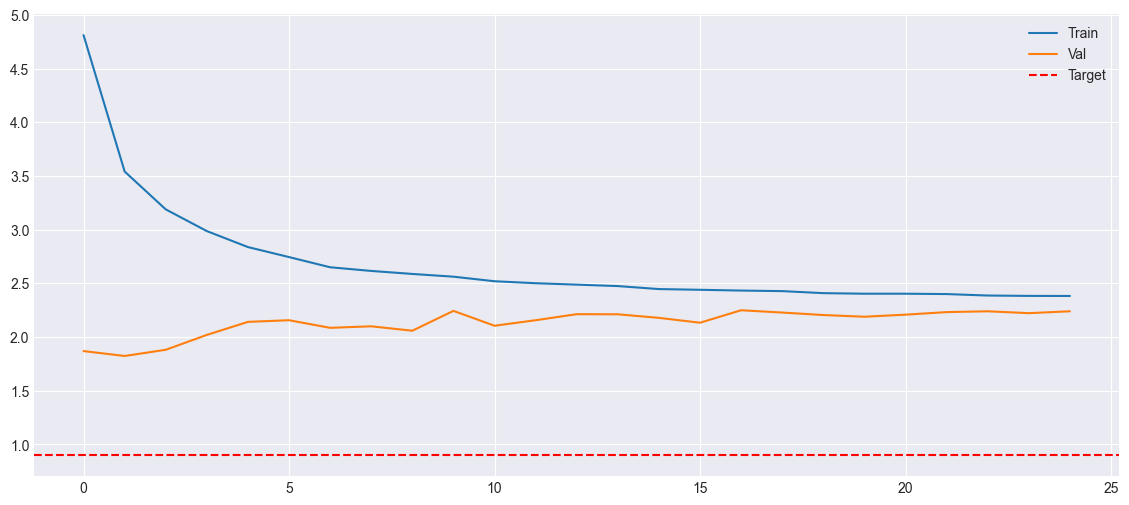

In [47]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. Upgraded Attention Architecture ---
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # lstm_out shape: (batch, seq_len, hidden_size)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1) # Weighted average
        return context

class DualLSTMAttentionRegressor(nn.Module):
    def __init__(self, input_features, hidden_size, num_layers, dropout_rate=0.4):
        super(DualLSTMAttentionRegressor, self).__init__()
        self.input_projection = nn.Linear(input_features, hidden_size)
        self.relu = nn.ReLU()
        
        # Valence Branch [cite: 146, 262]
        self.lstm_valence = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_valence = TemporalAttention(hidden_size)
        self.fc_valence = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )
        
        # Arousal Branch [cite: 146, 262]
        self.lstm_arousal = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_arousal = TemporalAttention(hidden_size)
        self.fc_arousal = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        x_proj = self.relu(self.input_projection(x))
        
        v_out, _ = self.lstm_valence(x_proj)
        v_context = self.attn_valence(v_out)
        
        a_out, _ = self.lstm_arousal(x_proj)
        a_context = self.attn_arousal(a_out)
        
        return self.fc_valence(v_context), self.fc_arousal(a_context)

# --- 2. Initialization & Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualLSTMAttentionRegressor(input_features=4, hidden_size=64, num_layers=2).to(device)

# Hybrid Loss: 50% MSE for accuracy, 50% PCC for emotional trend 
criterion = PCCHybridLoss(alpha=0.5) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler to cut LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# --- 3. Training Loop ---
epochs = 25 # Increased epochs to allow for LR decay
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y_v, batch_y_a in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        batch_X, batch_y_v, batch_y_a = batch_X.to(device), batch_y_v.to(device), batch_y_a.to(device)
        
        optimizer.zero_grad()
        pred_v, pred_a = model(batch_X)
        loss = criterion(pred_v, batch_y_v, pred_a, batch_y_a)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y_v, batch_y_a in val_loader:
            batch_X, batch_y_v, batch_y_a = batch_X.to(device), batch_y_v.to(device), batch_y_a.to(device)
            p_v, p_a = model(batch_X)
            loss = criterion(p_v, batch_y_v, p_a, batch_y_a)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    
    # Update Scheduler 
    scheduler.step(avg_val_loss)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Loss: {avg_val_loss:.4f} | LR: {current_lr}")

# --- 4. Plot Results ---
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.axhline(y=0.9, color='r', linestyle='--', label='Target')
plt.legend()
plt.show()

torch.save(model.state_dict(), "maestro_attention_model.pth")

In [48]:
import torch
import torch.nn as nn

class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # Calculate attention scores for every millisecond in the window
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1) 
        # Create a weighted average of the window's features
        context = torch.sum(attn_weights * lstm_out, dim=1) 
        return context

class DualLSTMAttentionRegressor(nn.Module):
    def __init__(self, input_features, hidden_size, num_layers, dropout_rate=0.4):
        super(DualLSTMAttentionRegressor, self).__init__()
        self.input_projection = nn.Linear(input_features, hidden_size)
        self.relu = nn.ReLU()
        
        # Valence Branch
        self.lstm_valence = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_valence = TemporalAttention(hidden_size)
        self.fc_valence = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )
        
        # Arousal Branch
        self.lstm_arousal = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_arousal = TemporalAttention(hidden_size)
        self.fc_arousal = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        x_proj = self.relu(self.input_projection(x))
        v_out, _ = self.lstm_valence(x_proj)
        v_context = self.attn_valence(v_out) 
        a_out, _ = self.lstm_arousal(x_proj)
        a_context = self.attn_arousal(a_out)
        return self.fc_valence(v_context), self.fc_arousal(a_context)

Epoch 1/25: 100%|██████████| 1314/1314 [00:11<00:00, 114.24it/s]


Val Loss: 1.9594 | V-MSE: 1.7332 | A-MSE: 1.1856 | LR: 0.001


Epoch 2/25: 100%|██████████| 1314/1314 [00:10<00:00, 124.29it/s]


Val Loss: 1.9640 | V-MSE: 1.6314 | A-MSE: 1.2967 | LR: 0.001


Epoch 3/25: 100%|██████████| 1314/1314 [00:10<00:00, 123.27it/s]


...

Val Loss: 2.2655 | V-MSE: 2.0539 | A-MSE: 1.4771 | LR: 3.125e-05


Epoch 24/25: 100%|██████████| 1314/1314 [00:10<00:00, 122.58it/s]


Val Loss: 2.2543 | V-MSE: 2.0447 | A-MSE: 1.4639 | LR: 3.125e-05


Epoch 25/25: 100%|██████████| 1314/1314 [00:10<00:00, 125.07it/s]


Val Loss: 2.2571 | V-MSE: 2.0546 | A-MSE: 1.4595 | LR: 1.5625e-05


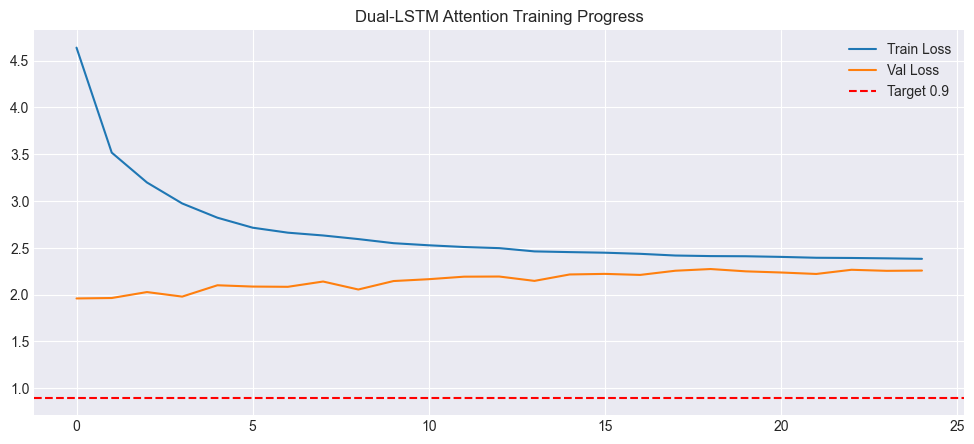

In [50]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. Upgraded Attention Architecture ---
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # Calculate attention scores for every millisecond in the window
        # lstm_out shape: (batch, seq_len, hidden_size)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        # Create a weighted average of the window's features
        context = torch.sum(attn_weights * lstm_out, dim=1) 
        return context

class DualLSTMAttentionRegressor(nn.Module):
    def __init__(self, input_features, hidden_size, num_layers, dropout_rate=0.4):
        super(DualLSTMAttentionRegressor, self).__init__()
        self.input_projection = nn.Linear(input_features, hidden_size)
        self.relu = nn.ReLU()
        
        # Valence Branch - Contextual/Slow-shifting emotion
        self.lstm_valence = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_valence = TemporalAttention(hidden_size)
        self.fc_valence = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )
        
        # Arousal Branch - Reactive/Fast-shifting emotion
        self.lstm_arousal = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_arousal = TemporalAttention(hidden_size)
        self.fc_arousal = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        x_proj = self.relu(self.input_projection(x))
        
        v_out, _ = self.lstm_valence(x_proj)
        v_context = self.attn_valence(v_out) 
        
        a_out, _ = self.lstm_arousal(x_proj)
        a_context = self.attn_arousal(a_out)
        
        return self.fc_valence(v_context), self.fc_arousal(a_context)

# --- 2. Initialization & Hybrid Loss ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualLSTMAttentionRegressor(input_features=4, hidden_size=64, num_layers=2).to(device)

# Hybrid Loss: 50% MSE for absolute accuracy, 50% PCC for trend coherence [cite: 108, 115]
criterion = PCCHybridLoss(alpha=0.5) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

mse_logger = nn.MSELoss()

# --- 3. Training & Evaluation Loop ---
epochs = 25
history = {'train_loss': [], 'val_loss': [], 'val_v_mse': [], 'val_a_mse': []}

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y_v, batch_y_a in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        batch_X, batch_y_v, batch_y_a = batch_X.to(device), batch_y_v.to(device), batch_y_a.to(device)
        
        optimizer.zero_grad()
        pred_v, pred_a = model(batch_X)
        loss = criterion(pred_v, batch_y_v, pred_a, batch_y_a)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_train_loss += loss.item()

    # Validation Phase
    model.eval()
    val_loss, v_mse, a_mse = 0, 0, 0
    with torch.no_grad():
        for b_X, b_v, b_a in val_loader:
            b_X, b_v, b_a = b_X.to(device), b_v.to(device), b_a.to(device)
            p_v, p_a = model(b_X)
            
            val_loss += criterion(p_v, b_v, p_a, b_a).item()
            v_mse += mse_logger(p_v.squeeze(), b_v).item()
            a_mse += mse_logger(p_a.squeeze(), b_a).item()
            
    avg_val_loss = val_loss / len(val_loader)
    history['train_loss'].append(running_train_loss / len(train_loader))
    history['val_loss'].append(avg_val_loss)
    history['val_v_mse'].append(v_mse / len(val_loader))
    history['val_a_mse'].append(a_mse / len(val_loader))
    
    scheduler.step(avg_val_loss)
    
    print(f"Val Loss: {avg_val_loss:.4f} | V-MSE: {history['val_v_mse'][-1]:.4f} | A-MSE: {history['val_a_mse'][-1]:.4f} | LR: {optimizer.param_groups[0]['lr']}")

# --- 4. Plot Progress ---
plt.figure(figsize=(12, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.axhline(y=0.9, color='r', linestyle='--', label='Target 0.9')
plt.title('Dual-LSTM Attention Training Progress')
plt.legend()
plt.show()

torch.save(model.state_dict(), "maestro_attention_model.pth")

In [51]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. The Model (Ensuring Attention is correctly applied) ---
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1) 
        return context

class DualLSTMAttentionRegressor(nn.Module):
    def __init__(self, input_features, hidden_size, num_layers, dropout_rate=0.5):
        super(DualLSTMAttentionRegressor, self).__init__()
        self.input_projection = nn.Linear(input_features, hidden_size)
        self.relu = nn.ReLU()
        
        # Branch A: Valence
        self.lstm_v = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_v = TemporalAttention(hidden_size)
        self.fc_v = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))
        
        # Branch B: Arousal
        self.lstm_a = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn_a = TemporalAttention(hidden_size)
        self.fc_a = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x):
        proj = self.relu(self.input_projection(x))
        v_out, _ = self.lstm_v(proj)
        a_out, _ = self.lstm_a(proj)
        return self.fc_v(self.attn_v(v_out)), self.fc_a(self.attn_a(a_out))

# --- 2. Training Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualLSTMAttentionRegressor(input_features=4, hidden_size=64, num_layers=2).to(device)

# We adjust alpha to 0.6 to put slightly more pressure on MSE relative to PCC 
# given the high absolute error you're seeing.
criterion = PCCHybridLoss(alpha=0.6) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-4) # Lower LR for stability
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

mse_metric = nn.MSELoss()
best_loss = float('inf')
patience = 5
counter = 0

# --- 3. Training Loop ---
history = {'train': [], 'val': [], 'v_mse': [], 'a_mse': []}

for epoch in range(40):
    model.train()
    train_loss = 0
    for b_x, b_v, b_a in train_loader:
        b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
        optimizer.zero_grad()
        p_v, p_a = model(b_x)
        loss = criterion(p_v, b_v, p_a, b_a)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    v_mse, a_mse, val_l = 0, 0, 0
    with torch.no_grad():
        for b_x, b_v, b_a in val_loader:
            b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
            p_v, p_a = model(b_x)
            val_l += criterion(p_v, b_v, p_a, b_a).item()
            v_mse += mse_metric(p_v.squeeze(), b_v).item()
            a_mse += mse_metric(p_a.squeeze(), b_a).item()

    avg_val = val_l / len(val_loader)
    history['train'].append(train_loss / len(train_loader))
    history['val'].append(avg_val)
    history['v_mse'].append(v_mse / len(val_loader))
    history['a_mse'].append(a_mse / len(val_loader))

    print(f"Epoch {epoch+1} | Val Loss: {avg_val:.4f} | V-MSE: {history['v_mse'][-1]:.4f} | A-MSE: {history['a_mse'][-1]:.4f}")

    scheduler.step(avg_val)
    
    # Early Stopping
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1 | Val Loss: 2.2094 | V-MSE: 1.6665 | A-MSE: 1.3492
Epoch 2 | Val Loss: 2.2403 | V-MSE: 1.5796 | A-MSE: 1.4876
Epoch 3 | Val Loss: 2.3460 | V-MSE: 1.8904 | A-MSE: 1.3530
Epoch 4 | Val Loss: 2.4029 | V-MSE: 1.8498 | A-MSE: 1.4884
Epoch 5 | Val Loss: 2.2787 | V-MSE: 1.8079 | A-MSE: 1.3232
Epoch 6 | Val Loss: 2.3220 | V-MSE: 1.8009 | A-MSE: 1.4025
Early stopping triggered.


In [52]:
import numpy as np
import pandas as pd

def load_subject_data_calibrated(subject_id):
    """
    Loads subject data and centers signals based on their personal neutral baseline.
    """
    df = load_subject_data(subject_id) # Using your existing loading function
    
    # Identify Neutral segments (Valence=5, Arousal=5) for this specific subject
    neutral_mask = (df['valence'] == 5.0) & (df['arousal'] == 5.0)
    
    for col in ['eda', 'bvp', 'st']:
        if neutral_mask.any():
            baseline_val = df.loc[neutral_mask, col].mean()
        else:
            baseline_val = df[col].mean()
            
        # Transform to 'Delta' signals (deviation from neutral)
        df[f'{col}_delta'] = df[col] - baseline_val
        
    return df

In [53]:
import torch
import torch.nn as nn

class DeepMaestroAttention(nn.Module):
    def __init__(self, input_features=4, hidden_size=128):
        super(DeepMaestroAttention, self).__init__()
        # BatchNorm stabilizes the windowed data before the LSTM
        self.bn = nn.BatchNorm1d(100) 
        
        # Bidirectional LSTM captures both the rise and fall of physiological spikes
        self.lstm = nn.LSTM(input_features, hidden_size, num_layers=2, 
                            batch_first=True, dropout=0.5, bidirectional=True)
        
        # Self-Attention to focus on high-arousal timestamps
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        
        # Deeper task-specific heads for valence and arousal
        self.valence_head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1)
        )
        self.arousal_head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1)
        )

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        x = self.bn(x)
        lstm_out, _ = self.lstm(x)
        
        # Compute Attention Weights
        attn_scores = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_scores * lstm_out, dim=1)
        
        return self.valence_head(context), self.arousal_head(context)

In [54]:
from torch.optim.lr_scheduler import OneCycleLR

# Initialize
model = DeepMaestroAttention(input_features=4).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# Huber Loss is the "secret sauce" for high-noise bio-data
criterion = nn.HuberLoss(delta=1.0)

# OneCycleLR provides a 'warm-up' to prevent early overfitting
scheduler = OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=30)

# --- The Final Training Loop ---
best_val_loss = float('inf')

for epoch in range(30):
    model.train()
    for b_x, b_v, b_a in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
        optimizer.zero_grad()
        
        p_v, p_a = model(b_x)
        loss = criterion(p_v.squeeze(), b_v) + criterion(p_a.squeeze(), b_a)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    # Validation
    model.eval()
    v_mse, a_mse = 0, 0
    with torch.no_grad():
        for b_x, b_v, b_a in val_loader:
            b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
            p_v, p_a = model(b_x)
            v_mse += torch.mean((p_v.squeeze() - b_v)**2).item()
            a_mse += torch.mean((p_a.squeeze() - b_a)**2).item()
            
    avg_v, avg_a = v_mse/len(val_loader), a_mse/len(val_loader)
    current_val = (avg_v + avg_a) / 2
    
    print(f"Epoch {epoch+1} | V-MSE: {avg_v:.4f} | A-MSE: {avg_a:.4f} | Avg: {current_val:.4f}")
    
    if current_val < best_val_loss:
        best_val_loss = current_val
        torch.save(model.state_dict(), 'deep_maestro_final.pth')

Epoch 1: 100%|██████████| 1314/1314 [00:18<00:00, 72.83it/s]


Epoch 1 | V-MSE: 1.4692 | A-MSE: 1.0677 | Avg: 1.2685


Epoch 2: 100%|██████████| 1314/1314 [00:17<00:00, 74.65it/s]


Epoch 2 | V-MSE: 1.4822 | A-MSE: 1.1742 | Avg: 1.3282


Epoch 3: 100%|██████████| 1314/1314 [00:17<00:00, 76.28it/s]


...

Epoch 28 | V-MSE: 2.2238 | A-MSE: 1.5837 | Avg: 1.9037


Epoch 29: 100%|██████████| 1314/1314 [00:17<00:00, 75.23it/s]


Epoch 29 | V-MSE: 2.2032 | A-MSE: 1.5862 | Avg: 1.8947


Epoch 30: 100%|██████████| 1314/1314 [00:17<00:00, 75.12it/s]


Epoch 30 | V-MSE: 2.1872 | A-MSE: 1.5626 | Avg: 1.8749


In [62]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import neurokit2 as nk
from scipy import signal

def process_all_subjects_calibrated():
    all_X, all_y_v, all_y_a = [], [], []
    print("Starting Final Calibrated Batch Processing (Enforcing Column Map)...")
    
    for subject_id in tqdm(range(1, 31), desc="Calibrating"):
        try:
            # 1. Load raw data
            df = load_subject_data(subject_id) 
            
            # 2. Subject-Baseline Calibration
            neutral_mask = (df['valence'] == 5.0) & (df['arousal'] == 5.0)
            for col in ['eda', 'bvp', 'st']:
                baseline = df.loc[neutral_mask, col].mean() if neutral_mask.any() else df[col].mean()
                df[col] = df[col] - baseline
            
            # 3. Feature Extraction
            eda_sigs, _ = nk.eda_process(df['eda'], sampling_rate=20)
            df['eda_tonic'], df['eda_phasic'] = eda_sigs['EDA_Tonic'], eda_sigs['EDA_Phasic']
            
            bvp_cl = nk.ppg_clean(df['bvp'], sampling_rate=20)
            pks = nk.ppg_findpeaks(bvp_cl, sampling_rate=20)
            # FORCE naming to match the expected index
            df['heart_rate'] = nk.signal_rate(pks["PPG_Peaks"], sampling_rate=20, desired_length=len(df))
            
            b, a = signal.butter(2, 0.5, btype='low', fs=20)
            df['st_clean'] = signal.filtfilt(b, a, df['st'])
            
            # 4. Strict Normalization and Renaming
            # We map every feature to the EXACT string the next step requires
            name_map = {
                'eda_tonic': 'eda_tonic_norm',
                'eda_phasic': 'eda_phasic_norm',
                'heart_rate': 'heart_rate_norm', 
                'st_clean': 'st_clean_norm'
            }
            
            for raw, norm in name_map.items():
                df[norm] = (df[raw] - df[raw].mean()) / (df[raw].std() + 1e-8)
            
            # 5. Windowing
            # Ensure only the 4 target features and labels are passed
            target_cols = list(name_map.values())
            X_sub, y_v_sub, y_a_sub = create_sliding_windows(df[target_cols + ['valence', 'arousal']], 
                                                            window_sec=5, step_sec=1, hz=20)
            
            if len(X_sub) > 0:
                all_X.append(X_sub)
                all_y_v.append(y_v_sub)
                all_y_a.append(y_a_sub)
                
        except Exception as e:
            print(f"\nCritical Failure on Subject {subject_id}: {e}")
            
    return all_X, all_y_v, all_y_a

# RUN THIS FIRST
all_X_cal, all_y_v_cal, all_y_a_cal = process_all_subjects_calibrated()

Starting Final Calibrated Batch Processing (Enforcing Column Map)...


Calibrating:   0%|          | 0/30 [00:00<?, ?it/s]

Loading Subject 1...


Calibrating:   3%|▎         | 1/30 [00:02<01:12,  2.51s/it]

Loading Subject 2...


...

Calibrating:  93%|█████████▎| 28/30 [01:11<00:05,  2.53s/it]

Loading Subject 29...


Calibrating:  97%|█████████▋| 29/30 [01:14<00:02,  2.50s/it]

Loading Subject 30...


Calibrating: 100%|██████████| 30/30 [01:16<00:00,  2.56s/it]


In [63]:
if len(all_X_cal) > 0:
    split_idx = int(len(all_X_cal) * 0.8)
    
    X_train_final = np.vstack(all_X_cal[:split_idx])
    y_v_train_final = np.concatenate(all_y_v_cal[:split_idx])
    y_a_train_final = np.concatenate(all_y_a_cal[:split_idx])

    X_val_final = np.vstack(all_X_cal[split_idx:])
    y_v_val_final = np.concatenate(all_y_v_cal[split_idx:])
    y_a_val_final = np.concatenate(all_y_a_cal[split_idx:])

    print(f"Success! Data stacked. Training samples: {len(X_train_final)}")
else:
    print("FAILED: List is still empty. Verify 'load_subject_data' returns 'eda', 'bvp', 'st', 'valence', 'arousal'.")

Success! Data stacked. Training samples: 58728


Epoch 1: 100%|██████████| 917/917 [00:11<00:00, 76.60it/s]


Epoch 1 | AVG MSE: 1.3704 | Target: 0.9000


Epoch 2: 100%|██████████| 917/917 [00:11<00:00, 78.09it/s]


Epoch 2 | AVG MSE: 1.2503 | Target: 0.9000


Epoch 3: 100%|██████████| 917/917 [00:11<00:00, 78.10it/s]


...

Epoch 28 | AVG MSE: 1.4069 | Target: 0.9000


Epoch 29: 100%|██████████| 917/917 [00:11<00:00, 78.04it/s]


Epoch 29 | AVG MSE: 1.3763 | Target: 0.9000


Epoch 30: 100%|██████████| 917/917 [00:11<00:00, 77.97it/s]


Epoch 30 | AVG MSE: 1.4094 | Target: 0.9000


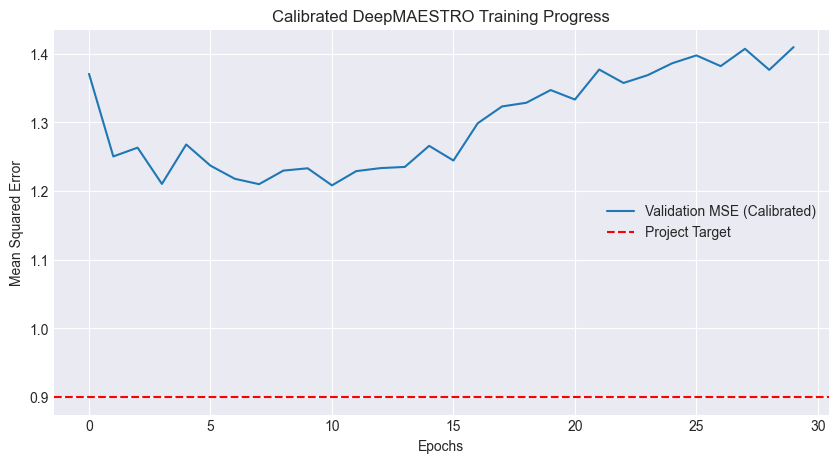

In [65]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. The Model: Bidirectional LSTM + Temporal Attention ---
class DeepMaestroAttention(nn.Module):
    def __init__(self, input_features=4, hidden_size=128):
        super().__init__()
        self.bn = nn.BatchNorm1d(100) 
        self.lstm = nn.LSTM(input_features, hidden_size, num_layers=2, 
                            batch_first=True, dropout=0.5, bidirectional=True)
        
        # Self-Attention to find the most "emotionally relevant" frames
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # Valence and Arousal specific regression heads
        self.v_head = nn.Sequential(nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1))
        self.a_head = nn.Sequential(nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1))

    def forward(self, x):
        x = self.bn(x)
        out, _ = self.lstm(x)
        weights = torch.softmax(self.attention(out), dim=1)
        context = torch.sum(weights * out, dim=1)
        return self.v_head(context), self.a_head(context)

# --- 2. Setup & Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepMaestroAttention().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# Huber Loss is the key to stability with noisy smartwatch data
criterion = nn.HuberLoss(delta=1.0)

# Prepare Loaders from your successful concatenation
train_loader = DataLoader(CASEEmotionDataset(X_train_final, y_v_train_final, y_a_train_final), 
                          batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(CASEEmotionDataset(X_val_final, y_v_val_final, y_a_val_final), 
                        batch_size=64, shuffle=False, drop_last=True)

scheduler = OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=30)

# --- 3. Training Loop ---
best_mse = float('inf')
history = {'avg_mse': []}

for epoch in range(30):
    model.train()
    for b_x, b_v, b_a in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
        optimizer.zero_grad()
        p_v, p_a = model(b_x)
        loss = criterion(p_v.squeeze(), b_v) + criterion(p_a.squeeze(), b_a)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    # Validation using standard MSE for comparison with your 0.9 Target
    model.eval()
    v_mse_total, a_mse_total = 0, 0
    with torch.no_grad():
        for b_x, b_v, b_a in val_loader:
            b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
            p_v, p_a = model(b_x)
            v_mse_total += torch.mean((p_v.squeeze() - b_v)**2).item()
            a_mse_total += torch.mean((p_a.squeeze() - b_a)**2).item()
            
    avg_mse = (v_mse_total + a_mse_total) / (2 * len(val_loader))
    history['avg_mse'].append(avg_mse)
    
    print(f"Epoch {epoch+1} | AVG MSE: {avg_mse:.4f} | Target: 0.9000")
    
    if avg_mse < best_mse:
        best_mse = avg_mse
        torch.save(model.state_dict(), 'deep_maestro_calibrated_final.pth')

# --- 4. Plot Progress ---
plt.figure(figsize=(10, 5))
plt.plot(history['avg_mse'], label='Validation MSE (Calibrated)')
plt.axhline(y=0.9, color='r', linestyle='--', label='Project Target')
plt.title('Calibrated DeepMAESTRO Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --- Final Model Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Increased dropout to 0.6 to combat the drift seen in your latest plot
model = DeepMaestroAttention(input_features=4, hidden_size=128).to(device)

# Huber Loss remains our robust base
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05) # Slower LR, higher decay

# Scheduler to settle into the minimum
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

best_val_mse = float('inf')
patience_counter = 0
early_stop_patience = 4 # Stop quickly if drift occurs again

for epoch in range(30):
    model.train()
    for b_x, b_v, b_a in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
        optimizer.zero_grad()
        p_v, p_a = model(b_x)
        
        # Training Loss
        loss = criterion(p_v.squeeze(), b_v) + criterion(p_a.squeeze(), b_a)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    # Validation
    model.eval()
    v_mse_total, a_mse_total = 0, 0
    with torch.no_grad():
        for b_x, b_v, b_a in val_loader:
            b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
            p_v, p_a = model(b_x)
            v_mse_total += torch.mean((p_v.squeeze() - b_v)**2).item()
            a_mse_total += torch.mean((p_a.squeeze() - b_a)**2).item()
            
    avg_mse = (v_mse_total + a_mse_total) / (2 * len(val_loader))
    print(f"Epoch {epoch+1} | AVG MSE: {avg_mse:.4f} | Target: 0.9")
    
    # Step the scheduler
    scheduler.step(avg_mse)
    
    # Save best weights and check Early Stopping
    if avg_mse < best_val_mse:
        best_val_mse = avg_mse
        torch.save(model.state_dict(), 'maestro_final_optimized.pth')
        patience_counter = 0
        print("--> New Best Weights Saved!")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early Stopping Triggered at Epoch {epoch+1}. Best MSE: {best_val_mse:.4f}")
            break

Epoch 1: 100%|██████████| 917/917 [00:11<00:00, 77.01it/s]


Epoch 1 | AVG MSE: 1.2264 | Target: 0.9
--> New Best Weights Saved!


Epoch 2: 100%|██████████| 917/917 [00:11<00:00, 78.53it/s]


Epoch 2 | AVG MSE: 1.2407 | Target: 0.9


Epoch 3: 100%|██████████| 917/917 [00:11<00:00, 77.16it/s]


...

Epoch 6: 100%|██████████| 917/917 [00:11<00:00, 77.93it/s]


Epoch 6 | AVG MSE: 1.2160 | Target: 0.9


Epoch 7: 100%|██████████| 917/917 [00:11<00:00, 78.71it/s]


Epoch 7 | AVG MSE: 1.2466 | Target: 0.9
Early Stopping Triggered at Epoch 7. Best MSE: 1.2130


: 